<a href="https://colab.research.google.com/github/Manimech121/Machine_Learning_Projects/blob/main/Jamboree_Education_Linear_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

Dataset

This dataset contains the details of 500 students who have applied for admission to IVY league college along with their success rate.

| Column Name                                                  | Description/Value Range                    |
|-------------------------------------------------------------|--------------------------------------------|
| Serial No.                                                  | Unique row ID                              |
| GRE Scores                                                  | Out of 340                                 |
| TOEFL Scores                                                | Out of 120                                 |
| University Rating                                           | Out of 5                                   |
| Statement of Purpose and Letter of Recommendation Strength  | Out of 5                                   |
| Undergraduate GPA                                           | Out of 10                                  |
| Research Experience                                         | Either 0 or 1                              |
| Chance of Admit                                             | Ranging from 0 to 1                        |




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv
To: /content/Jamboree_Admission.csv
100% 16.2k/16.2k [00:00<00:00, 42.6MB/s]


In [ ]:
df = pd.read_csv("Jamboree_Admission.csv")

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.head()




,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Checking for any Null values

In [ ]:
df.isna().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df.shape

(500, 9)

In [ ]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


Dropping the column "Serial No" since it doesnot add any value to the dataset

Exploratory Data Analysis

In [ ]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
df = df.rename(columns={'LOR ': 'LOR', 'Chance of Admit ': 'Chance of Admit'})

In [ ]:
df = df.drop(columns="Serial No.")


To Check for Duplicate rows

In [ ]:
duplicate_rows = df[df.duplicated()]
duplicate_rows

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit


Univariate Analysis

In [ ]:
sns.set_theme(style = 'dark')
def feature_countplot(ax, data, feature, title='Count Plot', xlabel=None, ylabel='Count', palette='viridis'):
    sns.countplot(data=data, x=feature, palette=palette, ax=ax)

    # Adding title and labels
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel if xlabel else feature, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # Customizing ticks
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Adding value annotations on top of the bars
    for p in ax.patches:
      ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)

/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette=palette, ax=ax)
/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette=palette, ax=ax)
/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette=palette, ax=ax)
/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

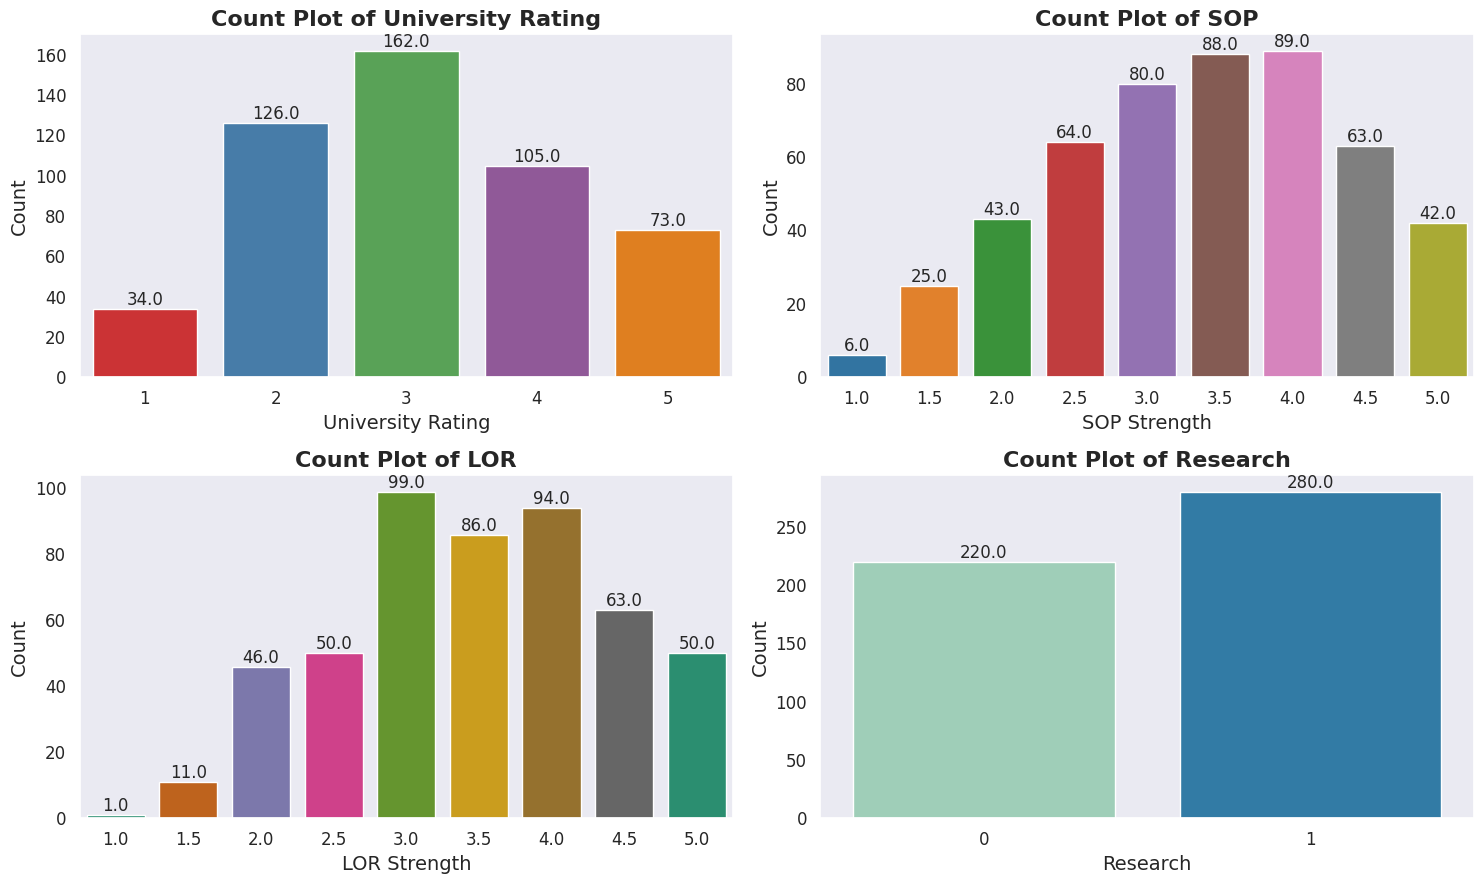

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 9))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

feature_countplot(axs[0, 0], data=df, feature='University Rating', title='Count Plot of University Rating', ylabel='Count', palette='Set1')
feature_countplot(axs[0, 1], data=df, feature='SOP', title='Count Plot of SOP', xlabel='SOP Strength', ylabel='Count', palette='tab10')
feature_countplot(axs[1, 0], data=df, feature='LOR', title='Count Plot of LOR', xlabel='LOR Strength', ylabel='Count', palette='Dark2')
feature_countplot(axs[1, 1], data=df, feature='Research', title='Count Plot of Research', xlabel='Research', ylabel='Count', palette='YlGnBu')

plt.tight_layout()
plt.show()

- Most common SOP and LOR have a strength in range 3-4

- Lot of people from universities with rating 2 or 3 appear for GRE

In [ ]:
def plot_distribution_and_box(ax, data, feature):
    # Distribution Plot (KDE)
    sns.kdeplot(data[feature], ax=ax[0], color='blue', fill=True, alpha=0.5, linewidth=2)
    ax[0].set_title(f'Distribution of {feature}', fontsize=16)
    ax[0].set_xlabel(feature, fontsize=14)
    ax[0].set_ylabel('Density', fontsize=14)

    # Box Plot
    sns.boxplot(x=data[feature], ax=ax[1], color='lightgray', palette='summer')
    ax[1].set_title(f'Box Plot of {feature}', fontsize=16)
    ax[1].set_xlabel(feature, fontsize=14)

/tmp/ipython-input-4283864110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data[feature], ax=ax[1], color='lightgray', palette='summer')
/tmp/ipython-input-4283864110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data[feature], ax=ax[1], color='lightgray', palette='summer')
/tmp/ipython-input-4283864110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data[feature], ax=ax[1], color='lightgray', palette='summer')
/tmp/ipython-input-4283864110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

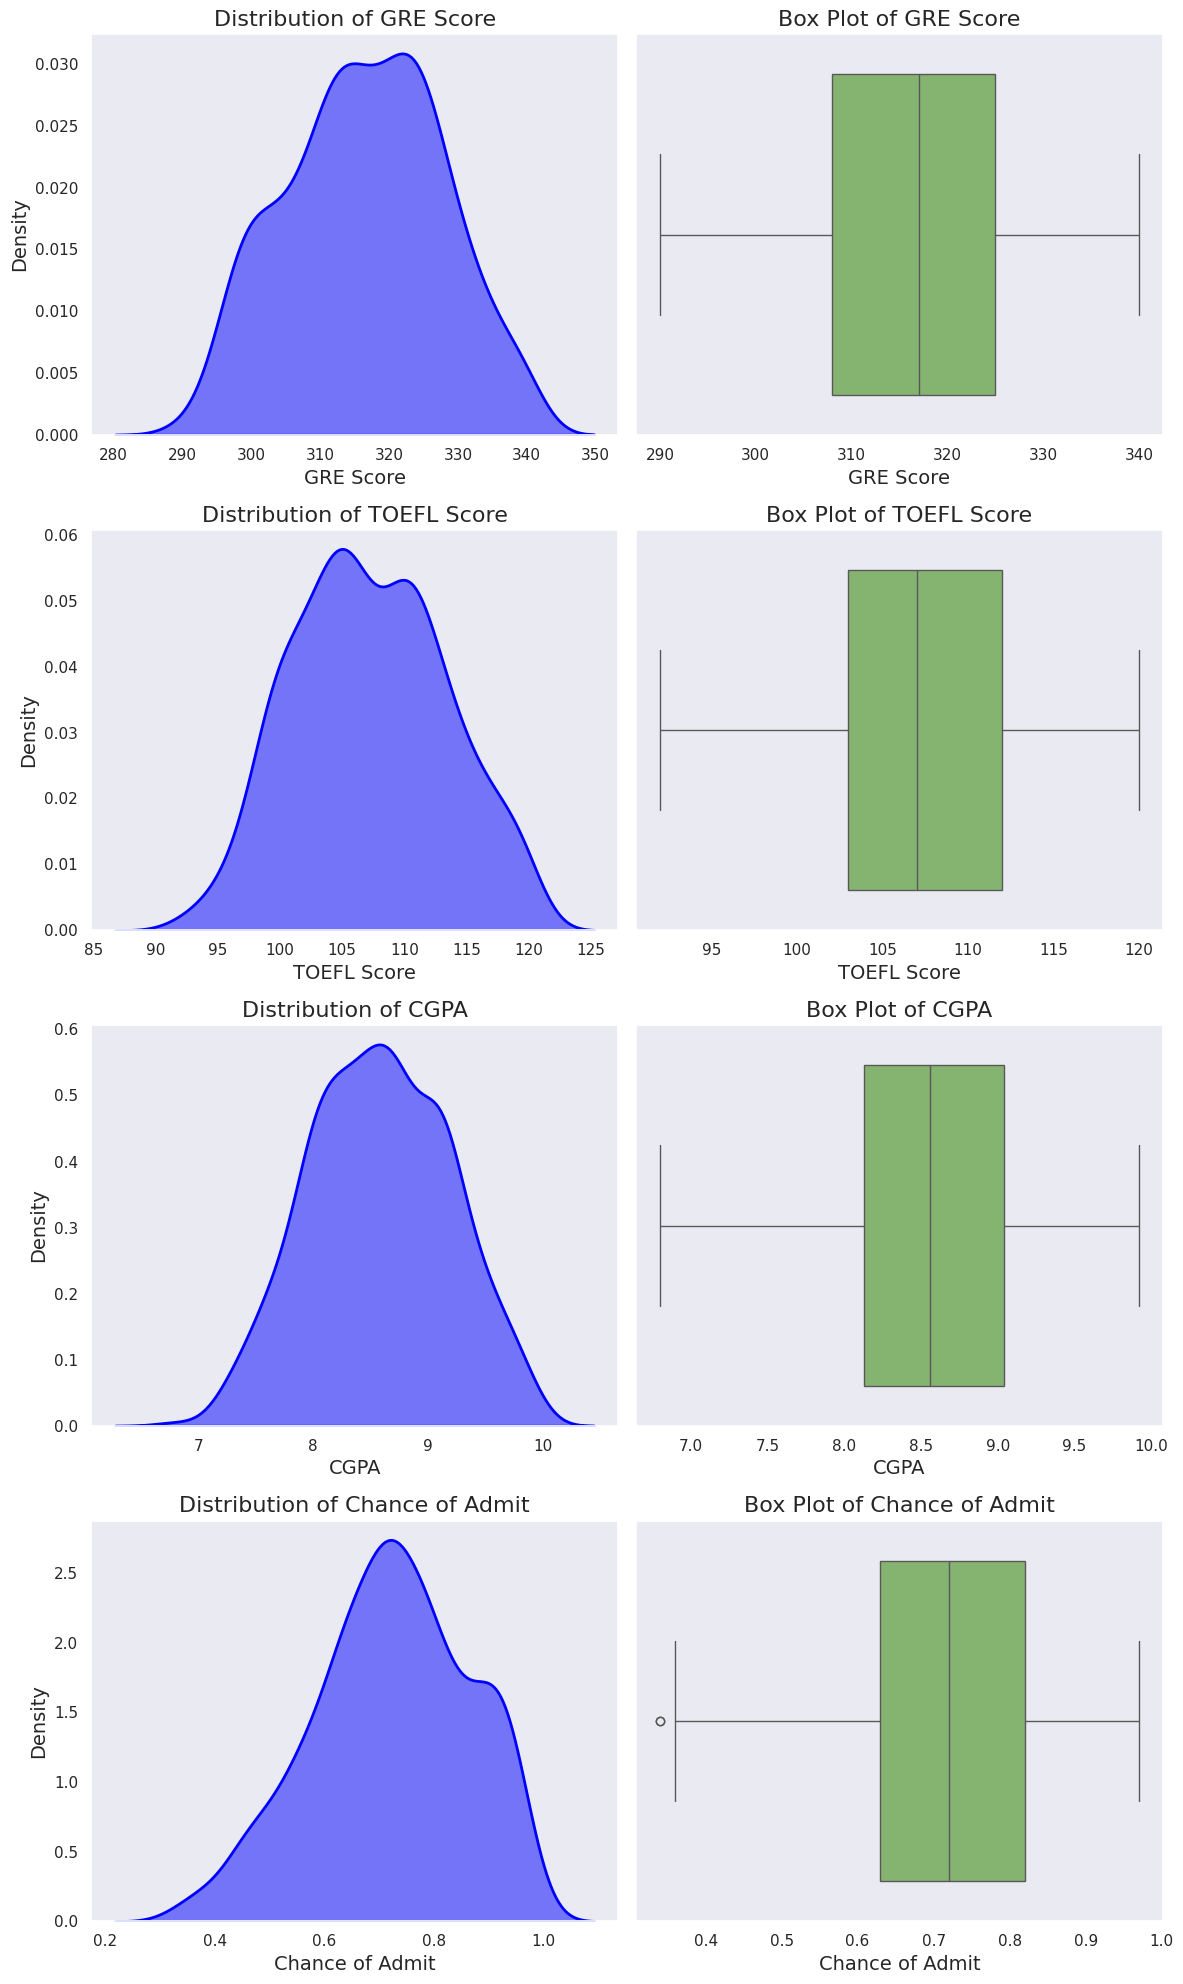

In [ ]:
fig, axs = plt.subplots(4, 2, figsize=(12, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

plot_distribution_and_box(axs[0], df, 'GRE Score')
plot_distribution_and_box(axs[1], df, 'TOEFL Score')
plot_distribution_and_box(axs[2], df, 'CGPA')
plot_distribution_and_box(axs[3], df, 'Chance of Admit')

plt.tight_layout()
plt.show()

- The GRE score among students typically ranges from 280 to 390, with the majority scoring between 310 and 325. This range covers scores accepted by many reputable programs in the US, with 300–325 considered competitive for a broad spectrum of universities.​

- TOEFL scores largely fall between 90 and 125, and most students score in the 103 to 112 band, matching the proficiency expectations of top institutions.​

- The CGPA is frequently between 8 and 9 on the 10-point scale, which aligns with the minimum or average requirements for mid- to top-tier programs. A CGPA in this range typically signals solid academic preparation.​

- The chance of admit for students in this dataset most commonly ranges between 70% and 80%, indicating that profiles meeting these academic benchmarks have a high probability of securing admission offers.

**From the above analysis it is clear that the features GRE Score, TOFEL Score and CGPA are normally distributed and have no outliers**



In [ ]:
sns.set_theme()
def correlation_plot(data, x_feature, y_feature, title='Scatter Plot', xlabel=None, ylabel=None):
    plt.figure(figsize=(9, 6))

    sns.scatterplot(data=data, x=x_feature, y=y_feature, alpha=0.7, color='blue')

    # Adding title and labels
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel if xlabel else x_feature, fontsize=14)
    plt.ylabel(ylabel if ylabel else y_feature, fontsize=14)

    plt.tight_layout()
    plt.show()

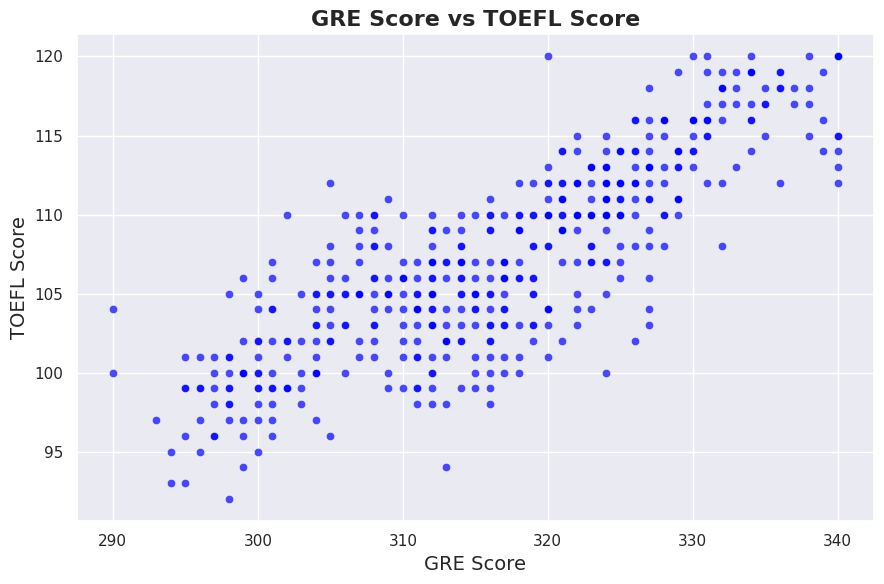

In [ ]:
correlation_plot(df, 'GRE Score', 'TOEFL Score', title='GRE Score vs TOEFL Score')

- GRE and TOEFL have a positive corelation, i.e, people with good GRE have a good TOEFL score



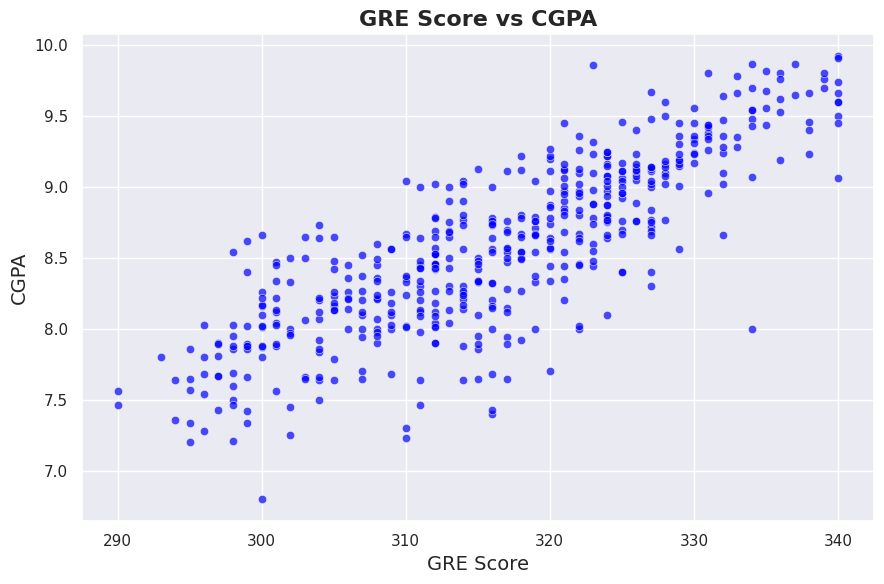

In [ ]:
correlation_plot(df, 'GRE Score', 'CGPA', title='GRE Score vs CGPA')

- GRE and CGPA also have a positive corelation, although not perfectly linear, the trend suggests that good CGPA is a reliable indicator for good GRE score

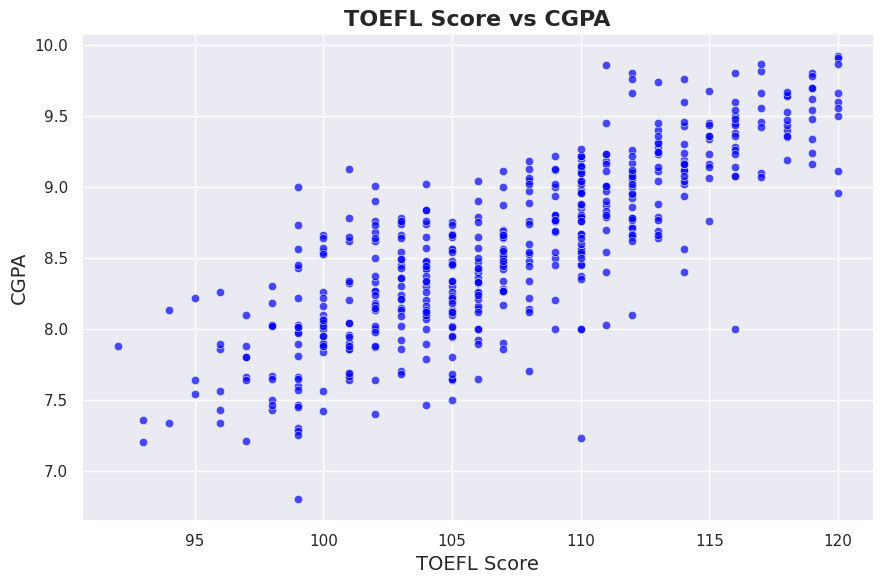

In [ ]:
correlation_plot(df, 'TOEFL Score', 'CGPA', title='TOEFL Score vs CGPA')


- There is some variability in CGPAs at similar TOEFL score levels, indicating that other factors might also influence academic performance.

In [ ]:
def feature_chances_of_admit(data, x_feature, hue_feature, title='Chance of Admit', palette='viridis'):
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="dark")

    # Create the KDE plot
    sns.kdeplot(
        data=data, x=x_feature, hue=hue_feature,
        fill=True, common_norm=False, palette=palette,
        alpha=0.5, linewidth=2
    )

    # Adding titles and labels
    plt.title(f'{title} by {hue_feature}', fontsize=16, fontweight='bold')
    plt.xlabel(x_feature, fontsize=14)
    plt.ylabel('Density', fontsize=14)

    # Customize the ticks
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()  # Adjust layout
    plt.show()

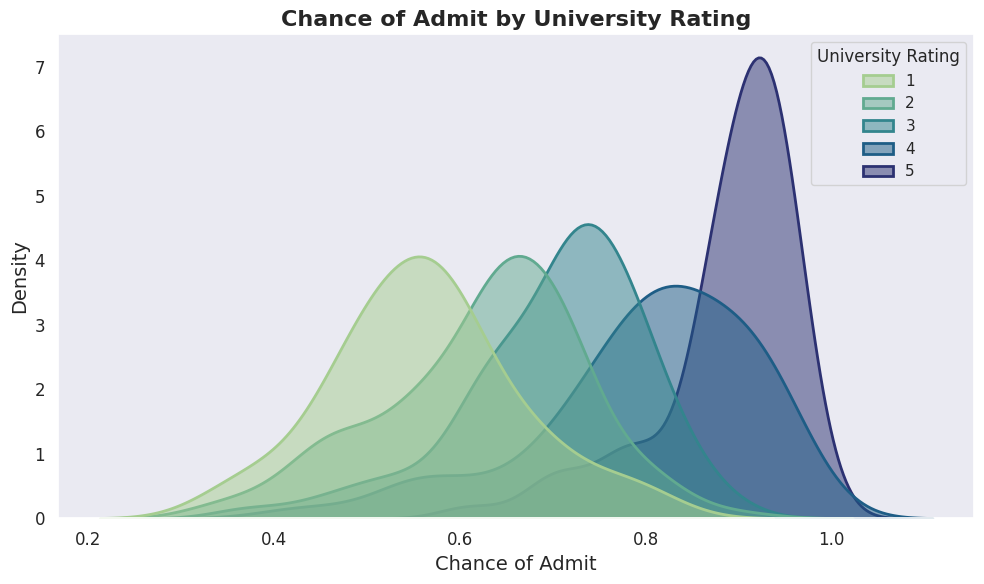

In [ ]:
feature_chances_of_admit(data=df, x_feature='Chance of Admit', hue_feature='University Rating', palette='crest')

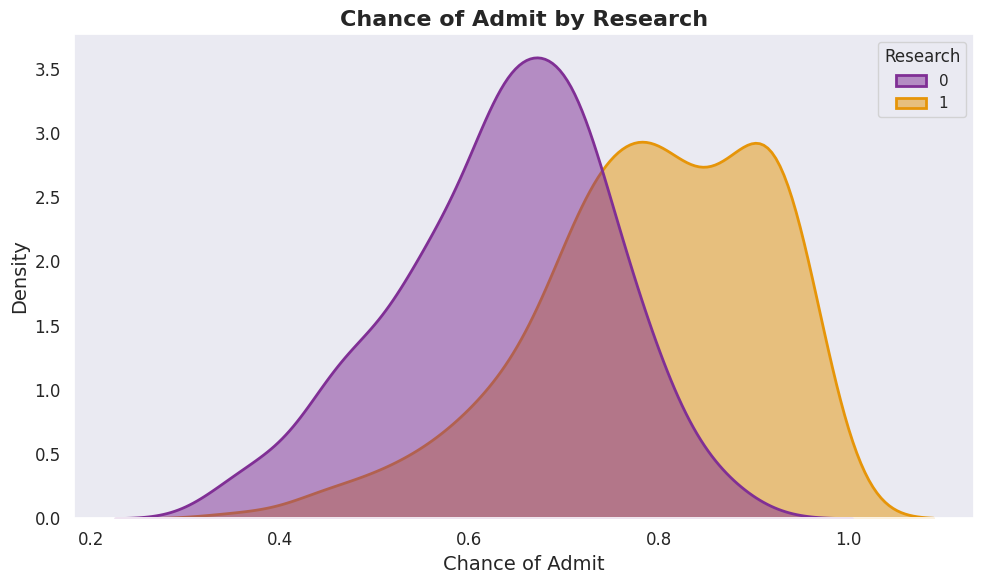

In [ ]:
feature_chances_of_admit(data=df, x_feature='Chance of Admit', hue_feature='Research', palette='CMRmap')

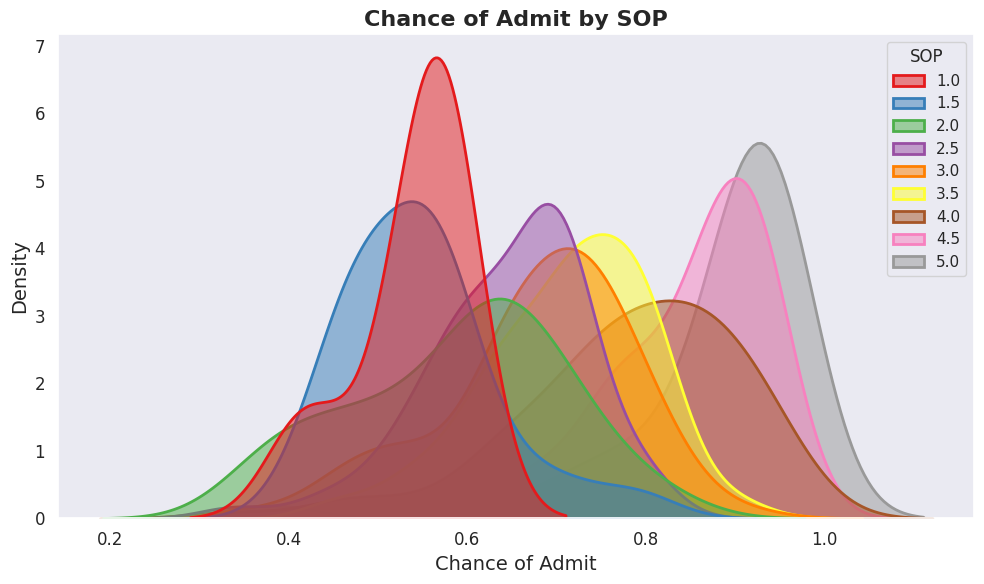

In [ ]:
feature_chances_of_admit(data=df, x_feature='Chance of Admit', hue_feature='SOP', palette='Set1')

/tmp/ipython-input-921699928.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


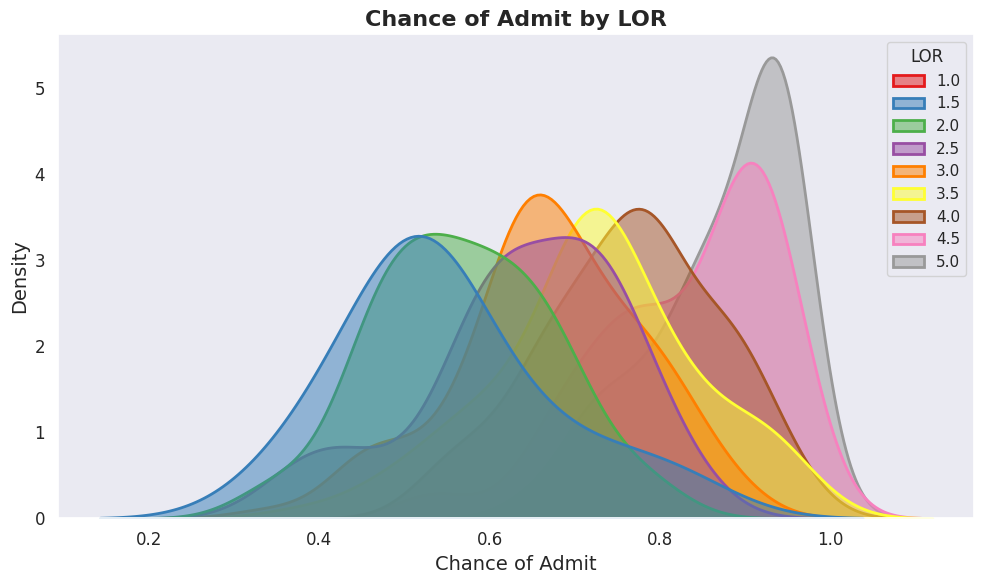

In [ ]:
feature_chances_of_admit(data=df, x_feature='Chance of Admit', hue_feature='LOR', palette='Set1')

- chances of admit increase with good Univertiy rating, strong LOR and SOP, and, some research experince

**Multivariate Analysis**

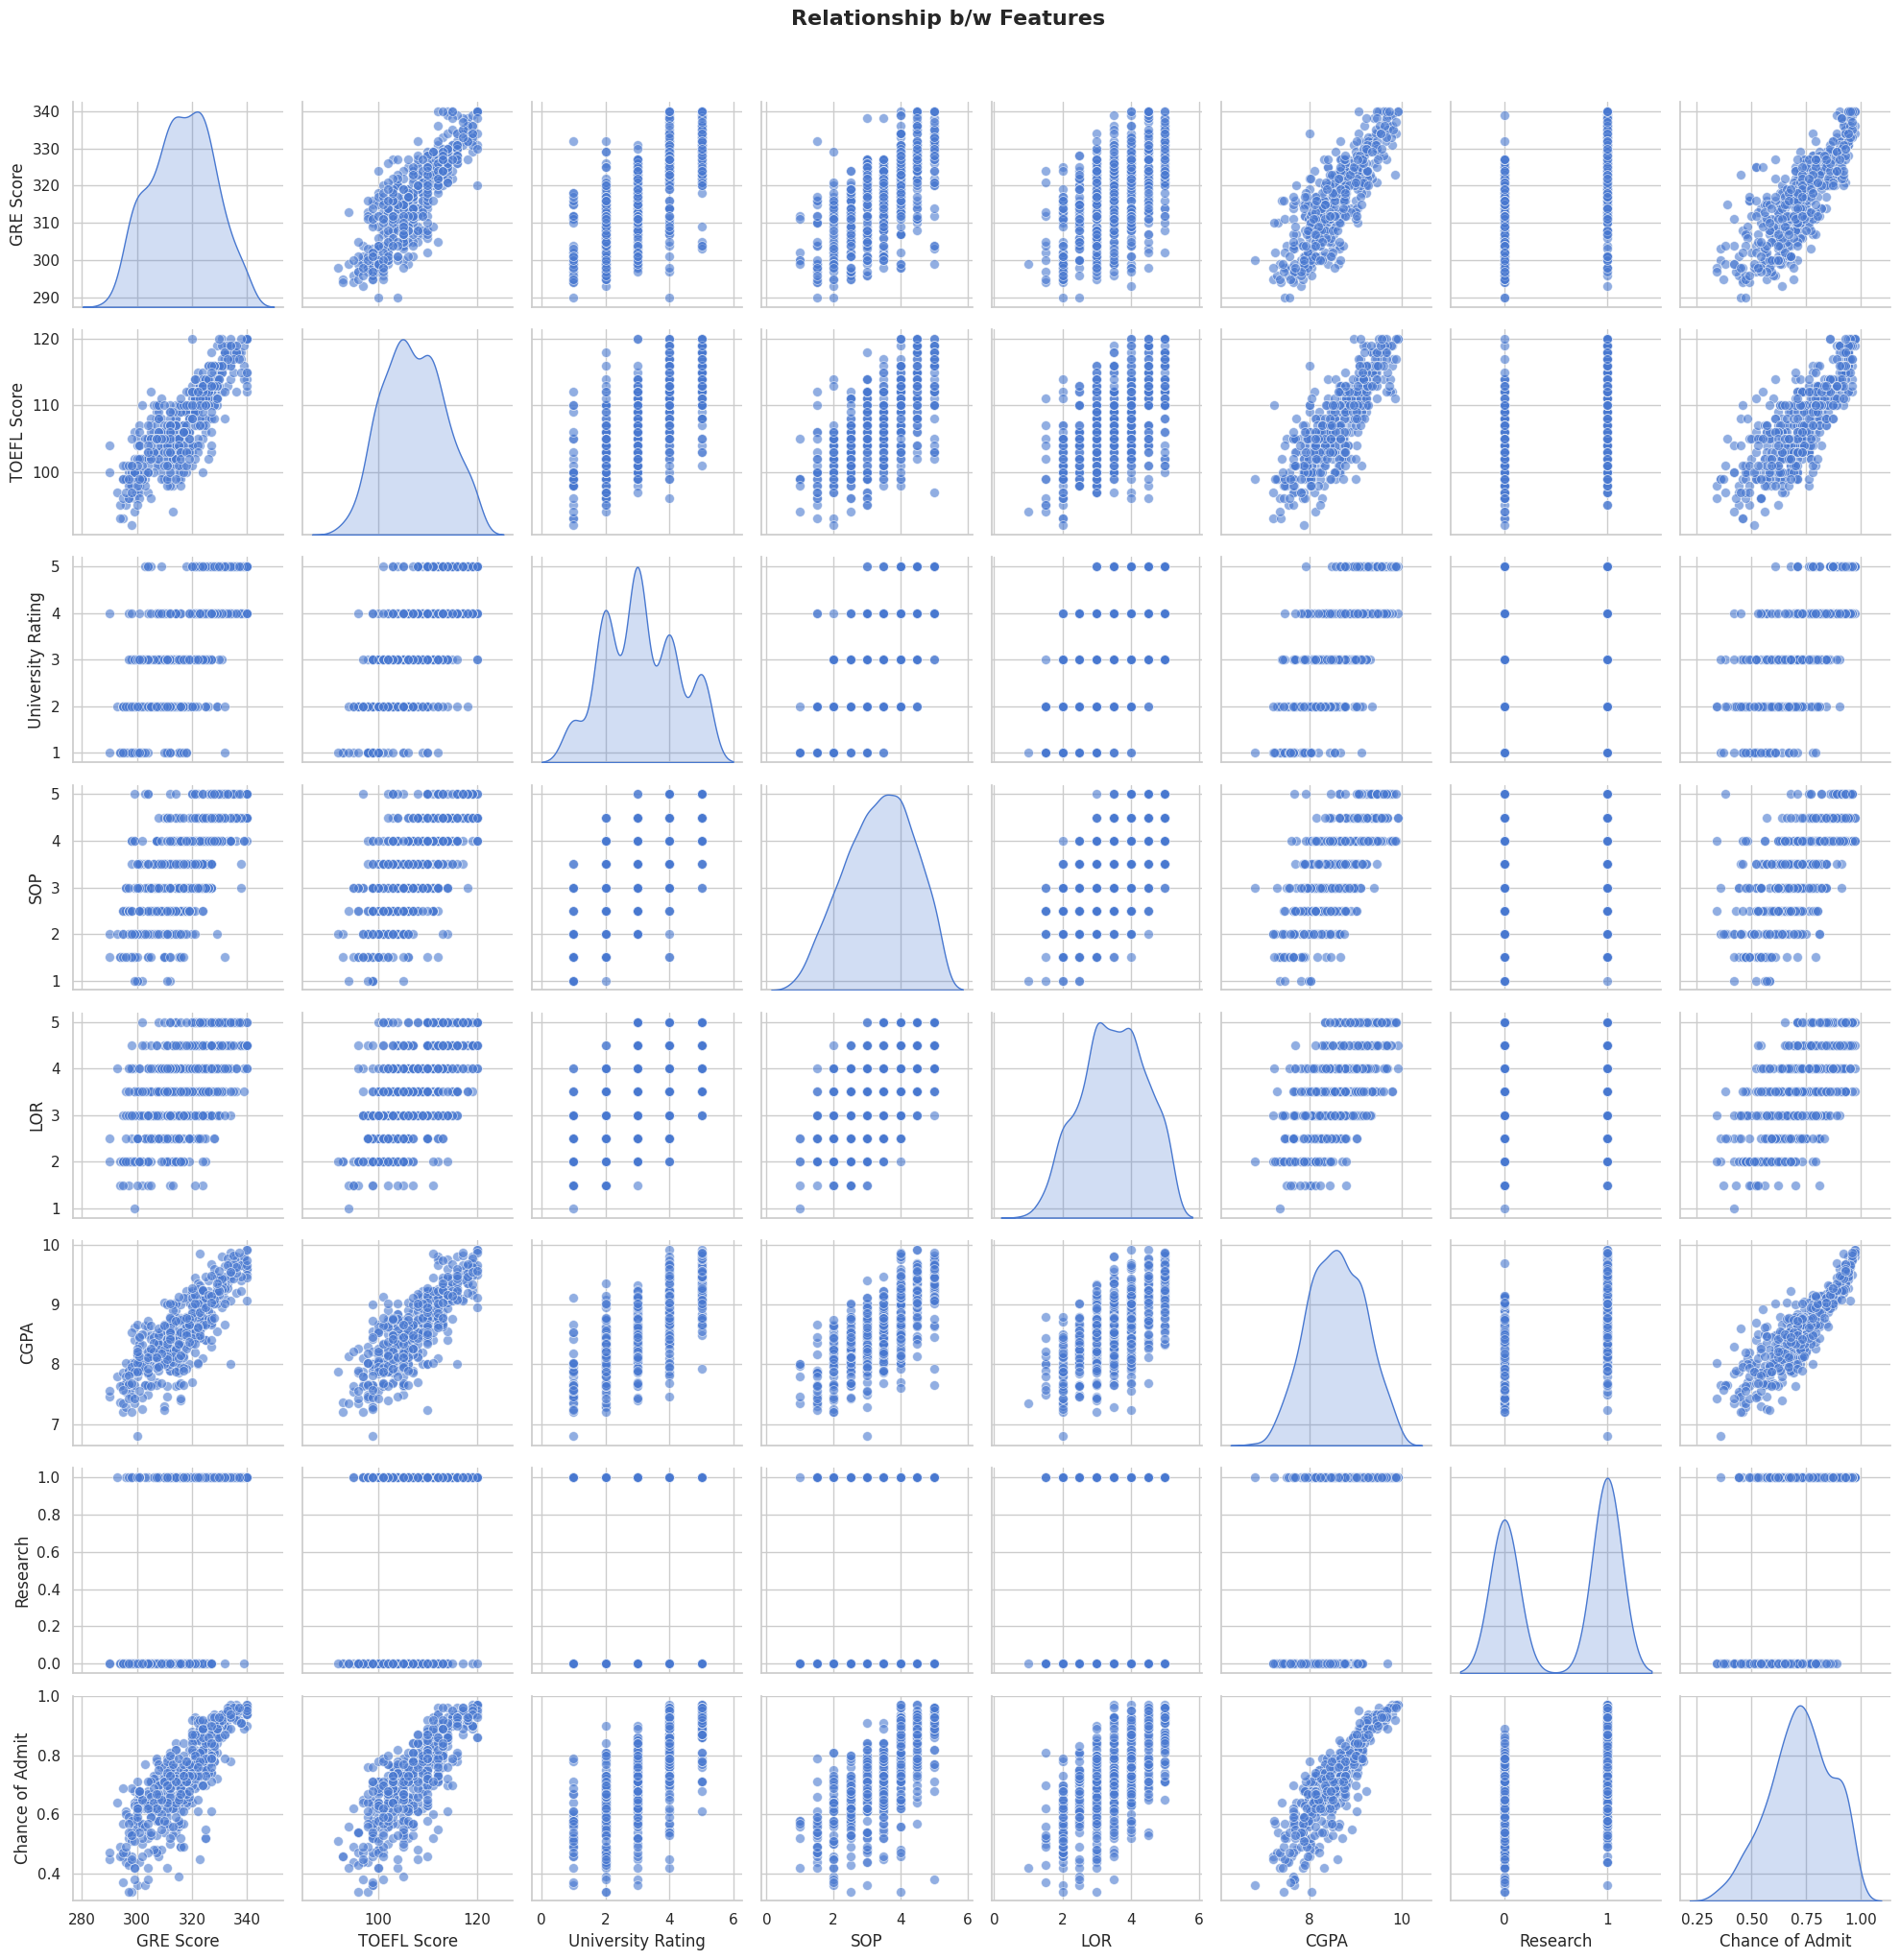

In [ ]:
sns.set(style="whitegrid", palette="muted")

pair_plot = sns.pairplot(df, diag_kind="kde", markers="o", plot_kws={'alpha':0.6, 's':50})
pair_plot.fig.suptitle('Relationship b/w Features', y=1.02, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

- GRE, TOEFL, and CGPA scores exhibit a strong positive correlation with the chance of admission. Higher scores in these metrics typically increase the likelihood of receiving an offer.

- University ranking, SOP rating, and LOR rating have a moderate influence on admission chances. While not as decisive as standardized test scores or academic performance, these factors can help differentiate applicants with similar profiles.

- Research experience is the least impactful feature in this dataset, suggesting it's not a significant determinant of admit probability for the majority of students, unless specific programs prioritize research background

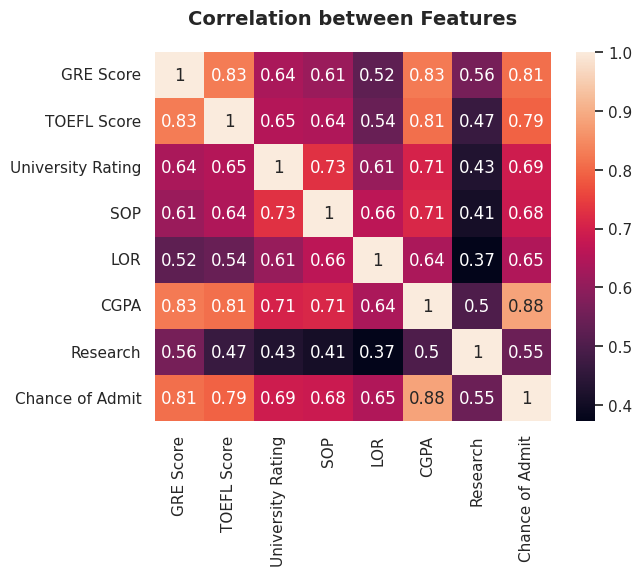

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation between Features', fontsize=14, fontweight='bold', pad=20)
plt.show()

- GRE, TOEFL and CGPA have high correlation with Chance of Admit

In [ ]:
duplicate_rows = df[df.duplicated()]
duplicate_rows

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit


In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

Standardizing all the datapoints to minmax scaler in order to perform the operations on the dataset

In [ ]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled  = pd.DataFrame(df_scaled,columns=df.columns)

In [ ]:
df_scaled.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0.94,0.928571,0.75,0.875,0.875,0.913462,1.0,0.920635
1,0.68,0.535714,0.75,0.750,0.875,0.663462,1.0,0.666667
2,0.52,0.428571,0.50,0.500,0.625,0.384615,1.0,0.603175
3,0.64,0.642857,0.50,0.625,0.375,0.599359,1.0,0.730159
4,0.48,0.392857,0.25,0.250,0.500,0.451923,0.0,0.492063


In [ ]:
y = df_scaled['Chance of Admit']
x = df_scaled.drop(columns = 'Chance of Admit')

Split the entire Dataset in to two ,one for training the model and other is to test the model

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.3,random_state=10)


In [ ]:
import statsmodels.api as sm

In [ ]:
xtest.shape

(150, 7)

# Add intercept manually

In [ ]:
xtrain_sm = sm.add_constant(xtrain)
xtest_sm = sm.add_constant(xtest)

In [ ]:
xtrain.shape

(350, 7)

In [ ]:
model = sm.OLS(ytrain,xtrain_sm).fit()


In [ ]:
y_pred = model.predict(xtest_sm)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
r2 = r2_score(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
mae = mean_absolute_error(ytest, y_pred)

print("R-squared on test data:", r2)
print("MSE on test data:", mse)
print("MAE on test data:", mae)


R-squared on test data: 0.8056353541641257
MSE on test data: 0.008375225422994957
MAE on test data: 0.06257829897396196


In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     231.8
Date:                Fri, 28 Nov 2025   Prob (F-statistic):          1.09e-125
Time:                        11:19:28   Log-Likelihood:                 323.68
No. Observations:                 350   AIC:                            -631.4
Df Residuals:                     342   BIC:                            -600.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0075      0.01

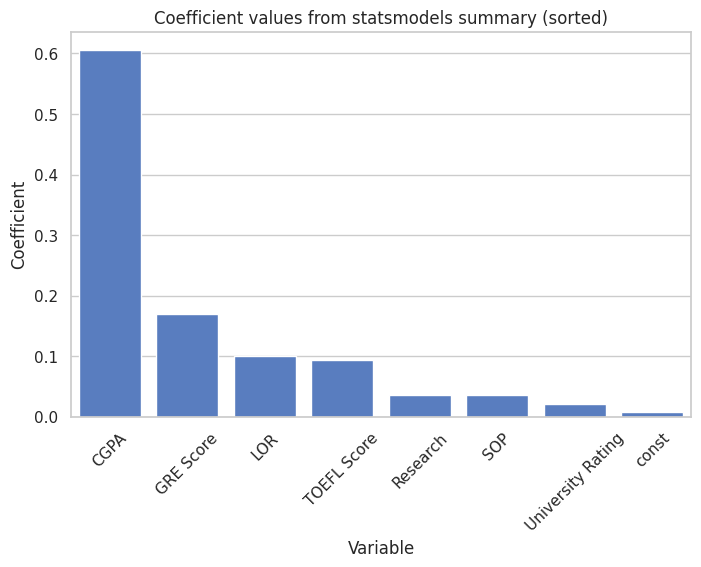

In [ ]:
coefficients = model.params

# Sort coefficients by absolute value in descending order
coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=coefficients_sorted.index, y=coefficients_sorted.values)
plt.xticks(rotation=45)
plt.title('Coefficient values from statsmodels summary (sorted)')
plt.ylabel('Coefficient')
plt.xlabel('Variable')
plt.show()

The test scores (CGPA, GRE ,LOR and TOEFL) have the heighest weight, i.e, they contribute more to the chance of admit
University Rating and SOP has the least weights

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

results_table =[]
for i in range(1,5):
  poly = PolynomialFeatures(degree=i,include_bias=False)
  x_poly_new = poly.fit_transform(x)
  feature_names = poly.get_feature_names_out(x.columns)
  x_poly_new = pd.DataFrame(x_poly_new,columns=feature_names)
  x_poly_train,x_poly_test,y_poly_train,y_poly_test = train_test_split(x_poly_new,y,test_size = 0.3,random_state=10)
  x_poly_train_sm = sm.add_constant(x_poly_train)
  x_poly_test_sm = sm.add_constant(x_poly_test)
  results = sm.OLS(y_poly_train,x_poly_train_sm).fit()
  y_poly_new_pred = results.predict(x_poly_test_sm)

  # Metrics
  train_r2 =  results.rsquared
  train_adj_r2 = results.rsquared_adj
  test_r2 = r2_score(y_poly_test, y_poly_new_pred)
  mse_poly = mean_squared_error(y_poly_test, y_poly_new_pred)
  mae_poly= mean_absolute_error(y_poly_test, y_poly_new_pred)
  results_table.append([i,train_r2,train_adj_r2,test_r2,mse_poly,mae_poly])

result_df = pd.DataFrame(results_table,columns = ["i","train_r2","train_adj_r2","test_r2","mse_poly","mae_poly"])

print(result_df)





   i  train_r2  train_adj_r2    test_r2  mse_poly  mae_poly
0  1  0.825912      0.822349   0.805635  0.008375  0.062578
1  2  0.841373      0.824251   0.805338  0.008388  0.063853
2  3  0.873387      0.814336   0.653546  0.014929  0.087206
3  4  0.981860      0.886951 -21.792480  0.982134  0.502072


**Linear Vs polynomial regression**

Linear regression gave test R2 score as 0.80 wheras Polynomial regression gave the Test RSquare as 0.81,there is no much of a difference in the R2 score,hence we consider Linear regression for this problem

Test the assumptions


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
vif = pd.DataFrame()
x_t = pd.DataFrame(xtrain,columns=xtrain.columns)
vif["Features"] =xtrain.columns
vif

,Features
0,GRE Score
1,TOEFL Score
2,University Rating
3,SOP
4,LOR
5,CGPA
6,Research


In [ ]:
vif_thr = 5
r2_thr = 0.85
i = 0
feats_removed = []
cols2 = vif["Features"][0:].values
while True:
  vif = pd.DataFrame()
  X_t = pd.DataFrame(xtrain, columns=xtrain.columns)[cols2]
  vif['Features'] = xtrain.columns
  vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
  vif['VIF'] = round(vif['VIF'], 2)
  vif = vif.sort_values(by = "VIF", ascending = False)

  cols2 = vif["Features"][1:].values
  X2 = pd.DataFrame(xtrain, columns=xtrain.columns)[cols2]

  X2_sm = sm.add_constant(X2)  #Statmodels default is without intercept, to add intercept we need to add constant
  sm_model = sm.OLS(list(ytrain), X2_sm).fit()
  if (vif.iloc[0]['VIF'] < vif_thr) or (sm_model.rsquared_adj < r2_thr):
    print('Reached threshold')
    print('Highest vif:',vif.iloc[0])
    print('Current adj.R2',sm_model.rsquared_adj)
    print('Features removed:', i)
    print('List of features removed:', feats_removed)
    break
  feats_removed.append(vif.iloc[0]['Features'])
  i += 1

Reached threshold
Highest vif: Features     CGPA
VIF         39.15
Name: 5, dtype: object
Current adj.R2 0.7647587399858189
Features removed: 0
List of features removed: []


In [ ]:
print(vif)
print(sm_model.summary())

            Features    VIF
5               CGPA  39.15
1        TOEFL Score  28.13
0          GRE Score  26.93
3                SOP  18.19
4                LOR  14.38
2  University Rating  10.60
6           Research   3.30
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     190.1
Date:                Fri, 28 Nov 2025   Prob (F-statistic):          7.43e-106
Time:                        11:19:28   Log-Likelihood:                 274.03
No. Observations:                 350   AIC:                            -534.1
Df Residuals:                     343   BIC:                            -507.1
Df Model:                           6                                         
Covariance Type:            nonrobust                            

In [ ]:
vif

,Features,VIF
5,CGPA,39.15
1,TOEFL Score,28.13
0,GRE Score,26.93
3,SOP,18.19
4,LOR,14.38
2,University Rating,10.60
6,Research,3.30


VIF indicates that multicolinearity between all the feartures are high but removing those features will impact the performance of the model

**Mean of residuals**

In [ ]:
errors = ytest-y_pred

Text(0.5, 1.0, 'Histogram of residuals')

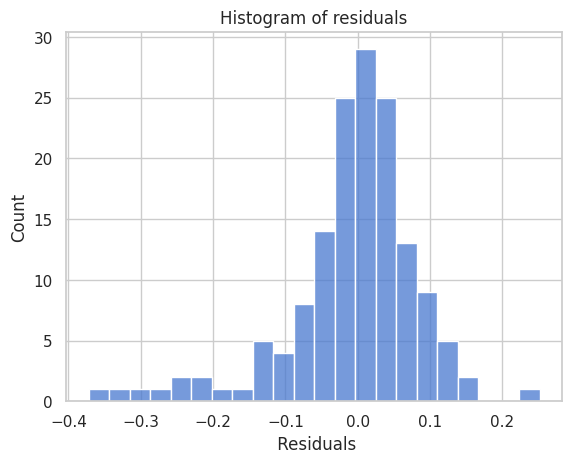

In [ ]:
import seaborn as sns

sns.histplot(errors)
plt.xlabel(" Residuals")
plt.title("Histogram of residuals")

In [ ]:
mean_residual = errors.mean()
print("Mean of residuals:", mean_residual)

Mean of residuals: -0.006997714633941768


The average error between your actual and predicted values is nearly zero.

This indicates your model does not have systematic bias in its predictions—on average, it neither consistently overestimates nor underestimates the outcome.

Such a low mean residual supports the validity and good calibration of your regression model

In [ ]:
stats.probplot(errors, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

NameError: name 'stats' is not defined

**Central points fit well:** In the middle range, residuals closely follow the expected normal curve, supporting the normality assumption for most of your data.

Minor tail deviations: **bold text** The deviation of extreme residuals (left and right tails) from the reference line suggests mild non-normality, especially in the tails

In [ ]:
from scipy import stats
res = stats.shapiro(errors)
res.statistic
res.pvalue

- A very low p-value suggests the residuals are not perfectly normal, often visible as deviations in a Q-Q plot.

In [ ]:
#Y_hat = model.predict(xtrain_sm)
#errors = Y_hat - ytrain


In [ ]:
sns.scatterplot(x=y_pred,y=errors)
plt.xlabel("predicted values")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")

**Test for Homoscedasticity**

In [ ]:
import matplotlib.pyplot as plt

# Assuming y_pred are your predicted values and residuals = y_test - y_pred
plt.scatter(y_pred, errors, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual vs. Predicted Values (Check for Homoscedasticity)')
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(errors, xtest_sm)

bp_stat = bp_test[0]  # Test statistic
bp_pvalue = bp_test[1]  # p-value

print('Breusch-Pagan test statistic:', bp_stat)
print('Breusch-Pagan p-value:', bp_pvalue)

- The p-value is 0.34, which is much higher than 0.05.

- This means you fail to reject the null hypothesis of homoscedasticity.

-  model's residuals do not show evidence of heteroscedasticity—the variance of the errors is constant across predicted values.

**Lasso and Ridge Regression**

In [ ]:
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso(alpha=0.001)  # Alpha is the regularization strength
ridge_model = Ridge(alpha=0.001)

In [ ]:
# Fit the models to the training data
lasso_model.fit(xtrain, ytrain)
ridge_model.fit(xtrain, ytrain)

In [ ]:
lasso_predictions = lasso_model.predict(xtest)
ridge_predictions = ridge_model.predict(xtest)

In [ ]:
print('test MSE for L1:', mean_squared_error(ytest, lasso_predictions))
print('test MSE for L2:', mean_squared_error(ytest, ridge_predictions))

In [ ]:
print("R^2 for lasso:",lasso_model.score(xtest, ytest))
print('R^2 for ridge:',ridge_model.score(xtest, ytest))

In [ ]:
residuals_lasso = ytest - lasso_predictions
residuals_Ridge = ytest - ridge_predictions

In [ ]:
plt.figure(figsize=(12, 4))

# Actual vs. Predicted
plt.subplot(1, 2, 1)
plt.scatter(ytest, lasso_predictions, color='blue')
plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red')  # Reference line
plt.title('Actual vs. Predicted (Lasso Linear Regression)')
plt.xlabel('Actual')
plt.ylabel('Predicted ')

# Actual vs. Residuals
plt.subplot(1, 2, 2)
plt.scatter(ytest, residuals_lasso, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Actual vs. Residuals (Lasso)')
plt.xlabel('Actual Values')
plt.ylabel('residuals_lasso')

plt.tight_layout()
plt.show()






In [ ]:
plt.figure(figsize=(12, 4))

# Actual vs. Predicted
plt.subplot(1, 2, 1)
plt.scatter(ytest, ridge_predictions, color='blue')
plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red')  # Reference line
plt.title('Actual vs. Predicted (Ridge Linear Regression)')
plt.xlabel('Actual')
plt.ylabel('Predicted ')

# Actual vs. Residuals
plt.subplot(1, 2, 2)
plt.scatter(ytest, residuals_Ridge, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Actual vs. Residuals (Ridge)')
plt.xlabel('Actual Values')
plt.ylabel('residuals_lasso')

plt.tight_layout()
plt.show()






**Model Fit (Actual vs. Predicted)**

Both Ridge and Lasso regression models show a strong linear relationship between the actual and predicted values. Most points cluster close to the diagonal reference line.

Ridge seems to slightly outperform Lasso visually, with tighter grouping around the reference line. Both methods can predict the target values with high accuracy within the tested range, reflecting robust model fitting.

**Residual Patterns (Actual vs. Residuals)**

In both residual plots, residuals are scattered close to zero, indicating that prediction errors do not show a systematic pattern. This supports the assumption of homoscedasticity and suggests unbiased estimates.

Ridge residuals seem slightly tighter (less variance), while Lasso shows a few larger negative outliers. This could mean that Ridge provides slightly more stable predictions on this dataset.

**Regularization Effects**

Lasso may set some coefficients exactly to zero, potentially causing greater residual spread for those instances where variable selection fails to capture certain signals.

Ridge, which shrinks coefficients smoothly rather than setting them to zero, maintains more consistent residual distribution and slightly stronger fit.

**Inference**

Both models are effective for linear regression on your data, but Ridge yields slightly better residual behavior and predictive accuracy.

No major signs of overfitting or problematic error patterns are visible in either model, supporting valid model assumptions for regression.

**Insights and Recommendations**

**Insights**

Both the base Linear Model and Ridge Model provide robust predictions with about 80% accuracy (R²).

High collinearity among CGPA, GRE, and TOEFL indicates their values are tightly related, which impacts coefficient interpretation more than overall accuracy.

University ratings and SOP have limited effect, while research experience, strong LOR, and well-crafted SOPs raise the likelihood of admission.

All key linear regression assumptions are satisfied based on residual diagnostics, although the Shapiro-Wilk test flags minor normality violations, which are common and not critical with adequate sample size and randomly scattered residuals.

**Recommendations**

**Value of Additional Data**

Since the chance of admit variable is right-skewed, suggesting relatively few rejections, gathering more data on students who were rejected will help balance the dataset and produce a model that learns from both successful and unsuccessful cases.​

Increased representation of rejections can enhance the reliability of predictions across the full range of outcomes, rather than only for high-performing applicants.

**Feature Engineering Suggestions**

Incorporating independent and diverse features is strongly supported in the literature for reducing collinearity and improving model performance:​

**Work Experience:** Quantifies practical skills, signaling readiness beyond academic performance.

**Internships:** Demonstrates hands-on expertise and relevance to target programs or fields.

**Extracurricular Activities:**  Reflects well-rounded character, leadership, and collaborative abilities valued by many institutions.

**Diversity Variables**:  Captures unique perspectives or backgrounds that can enrich campus diversity and help institutions meet broader recruitment goals.